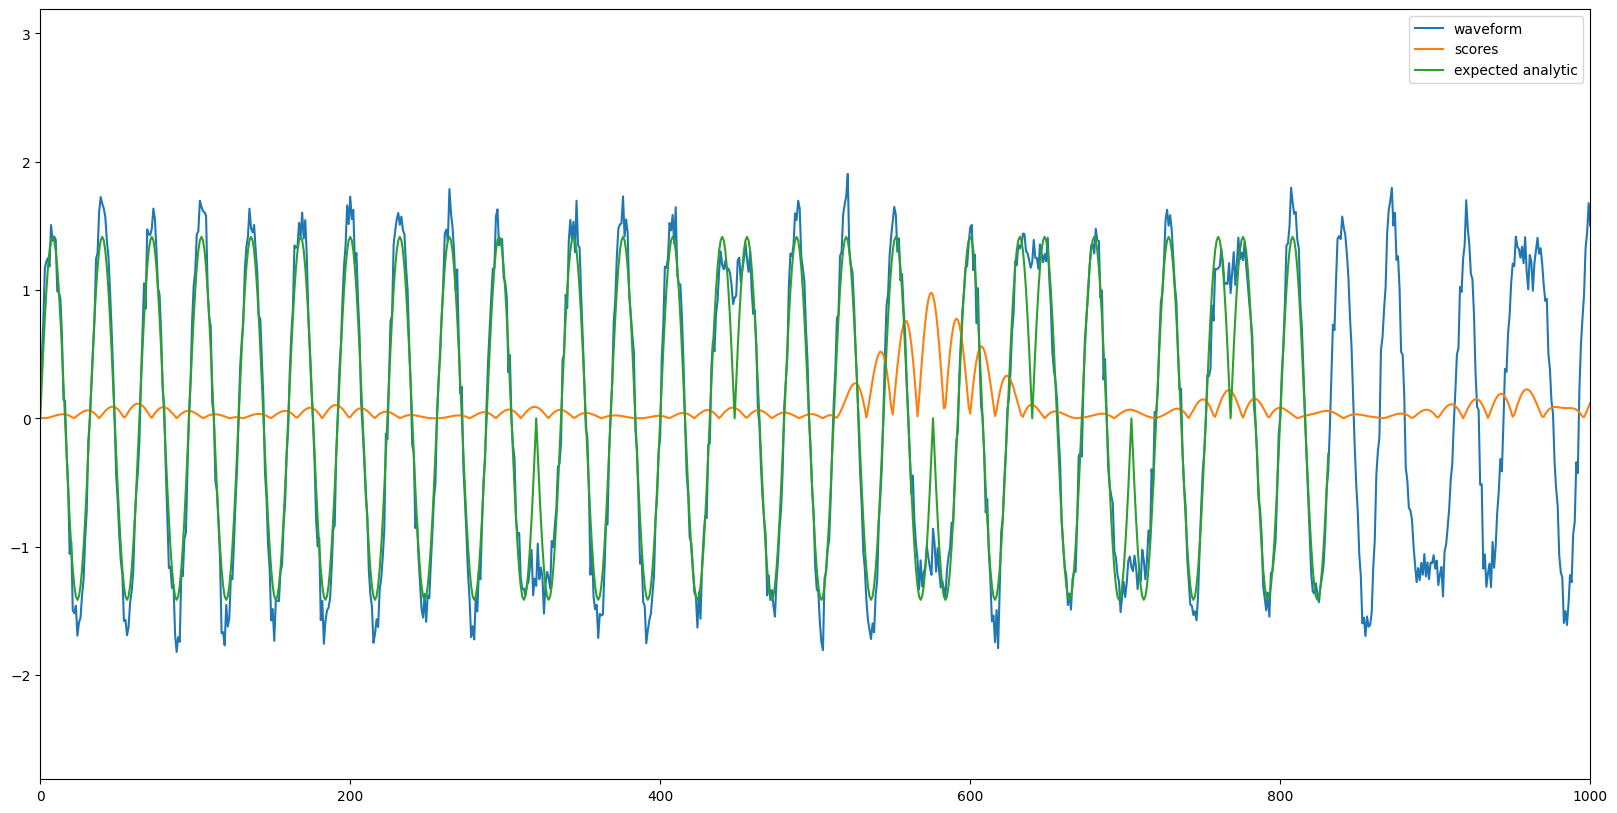

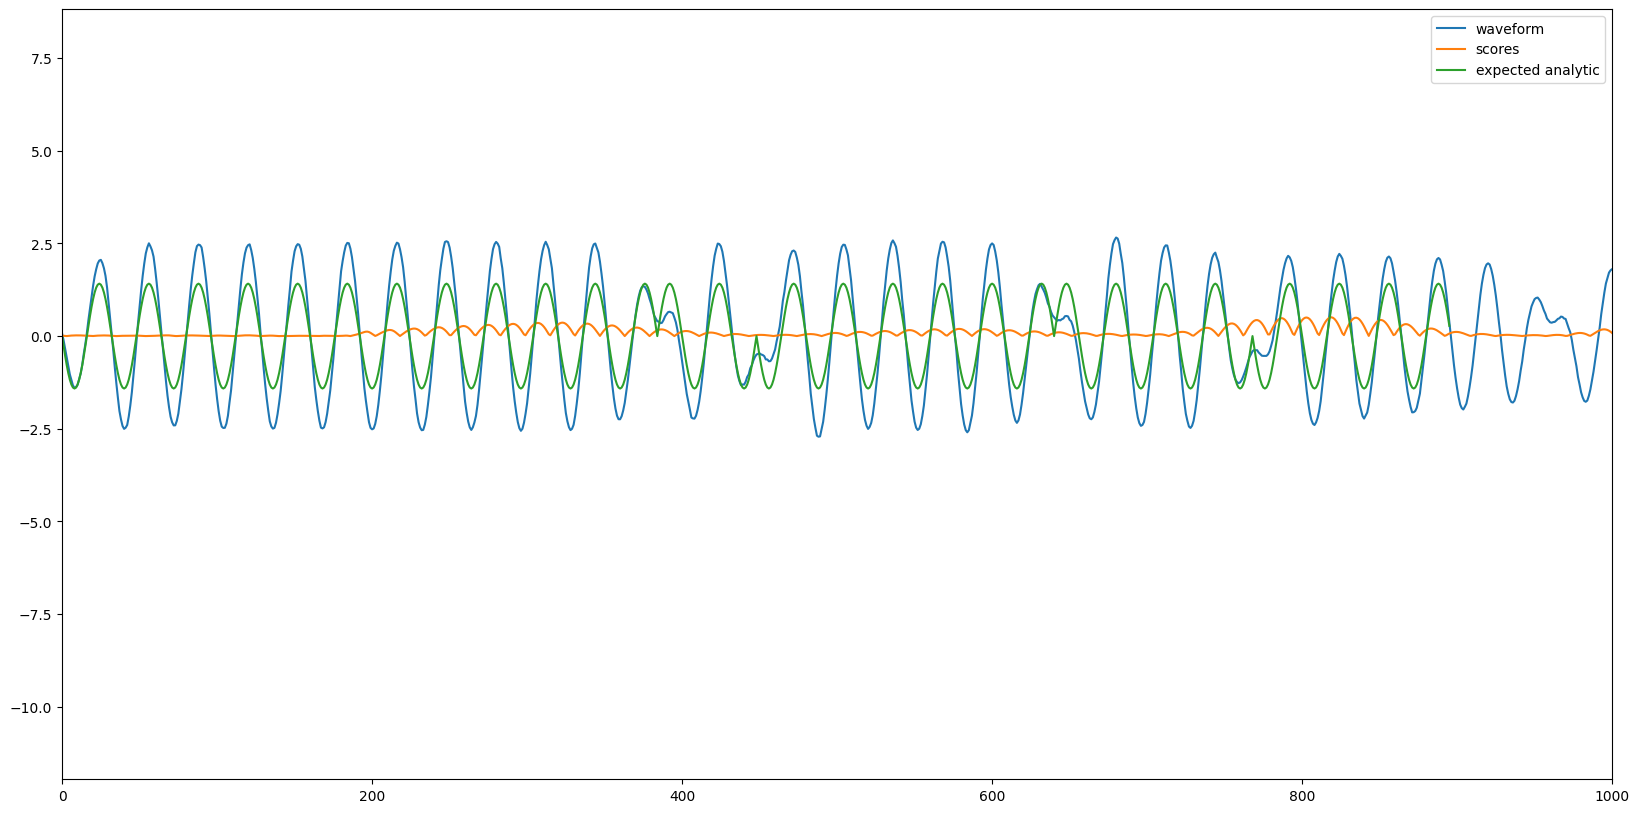

In [26]:
import matplotlib.pyplot as plt
import numpy as np


def plot_waveform_scores_expected_analytic(waveform, scores, expected_analytic):
    waveform = waveform / np.std(waveform)
    expected_analytic = expected_analytic / np.std(expected_analytic)

    plt.figure(figsize=(20, 10))
    plt.plot(
        waveform[np.argmax(scores) - expected_analytic.shape[0] // 2 :: 10],
        label="waveform",
    )
    plt.plot(scores[::10], label="scores")
    plt.plot(expected_analytic[::10], label="expected analytic")
    plt.xlim([0, 1000])
    plt.legend()


waveform = np.load("../../output/waveform.npy")
scores = np.abs(np.load("../../output/scores.npy"))
expected_analytic = np.load("../../output/expected_analytic.npy")
plot_waveform_scores_expected_analytic(waveform, scores, expected_analytic)
waveform2 = np.load("../../output/waveform2.npy")
scores2 = np.abs(np.load("../../output/scores2.npy"))
expected_analytic2 = np.load("../../output/expected_analytic2.npy")
plot_waveform_scores_expected_analytic(waveform2, scores2, expected_analytic2)

{'corr_same': 0.9804183971614109, 'corr_flipped': -0.9804183971614109}
{'corr_same': 0.9661738528600172, 'corr_flipped': -0.9661738528600172}


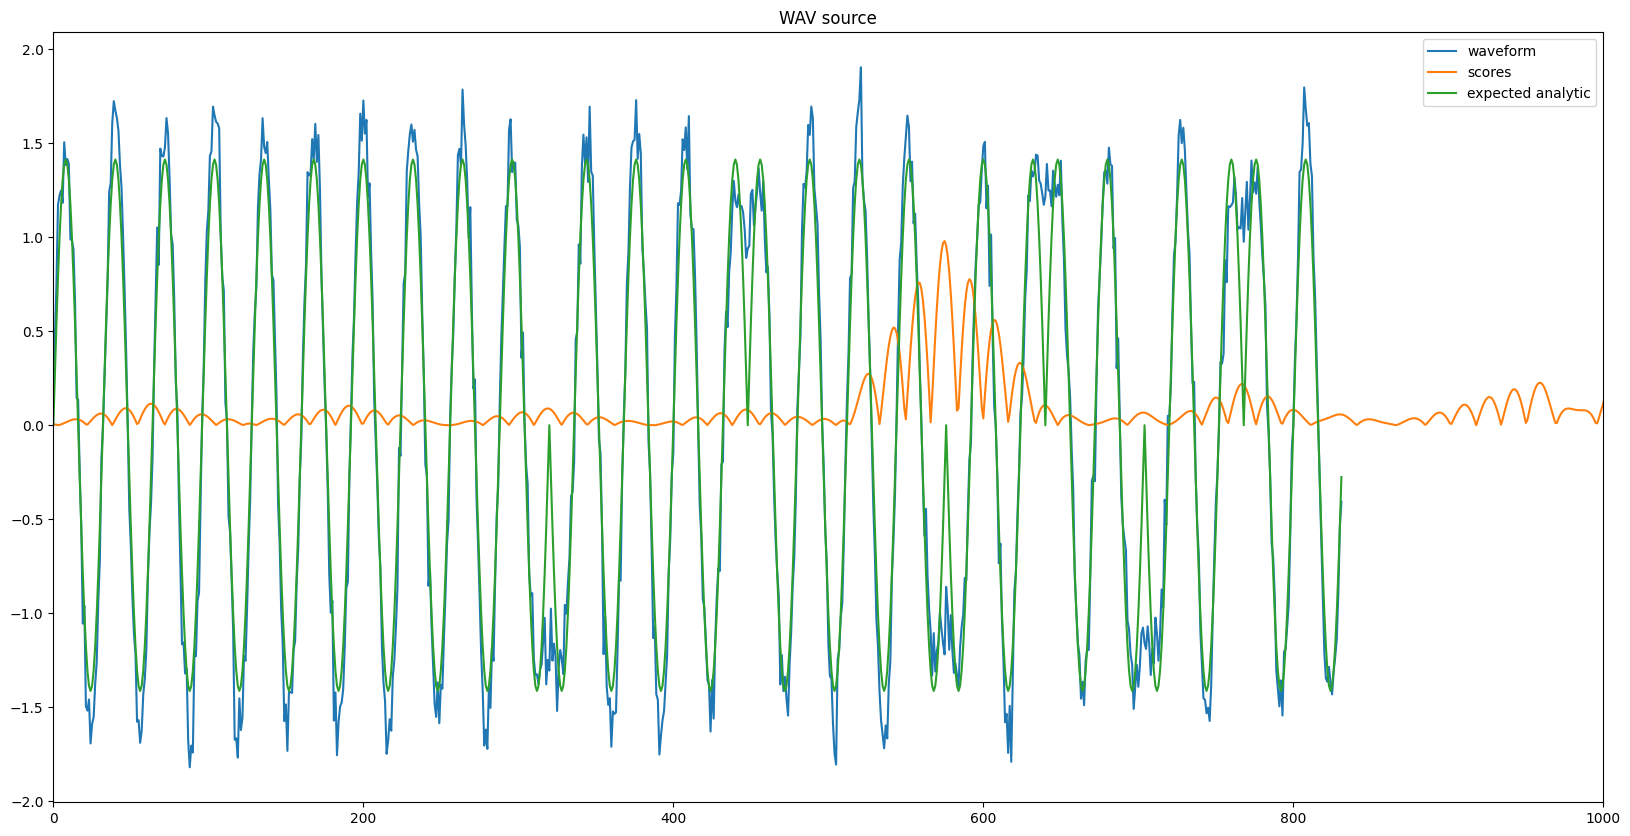

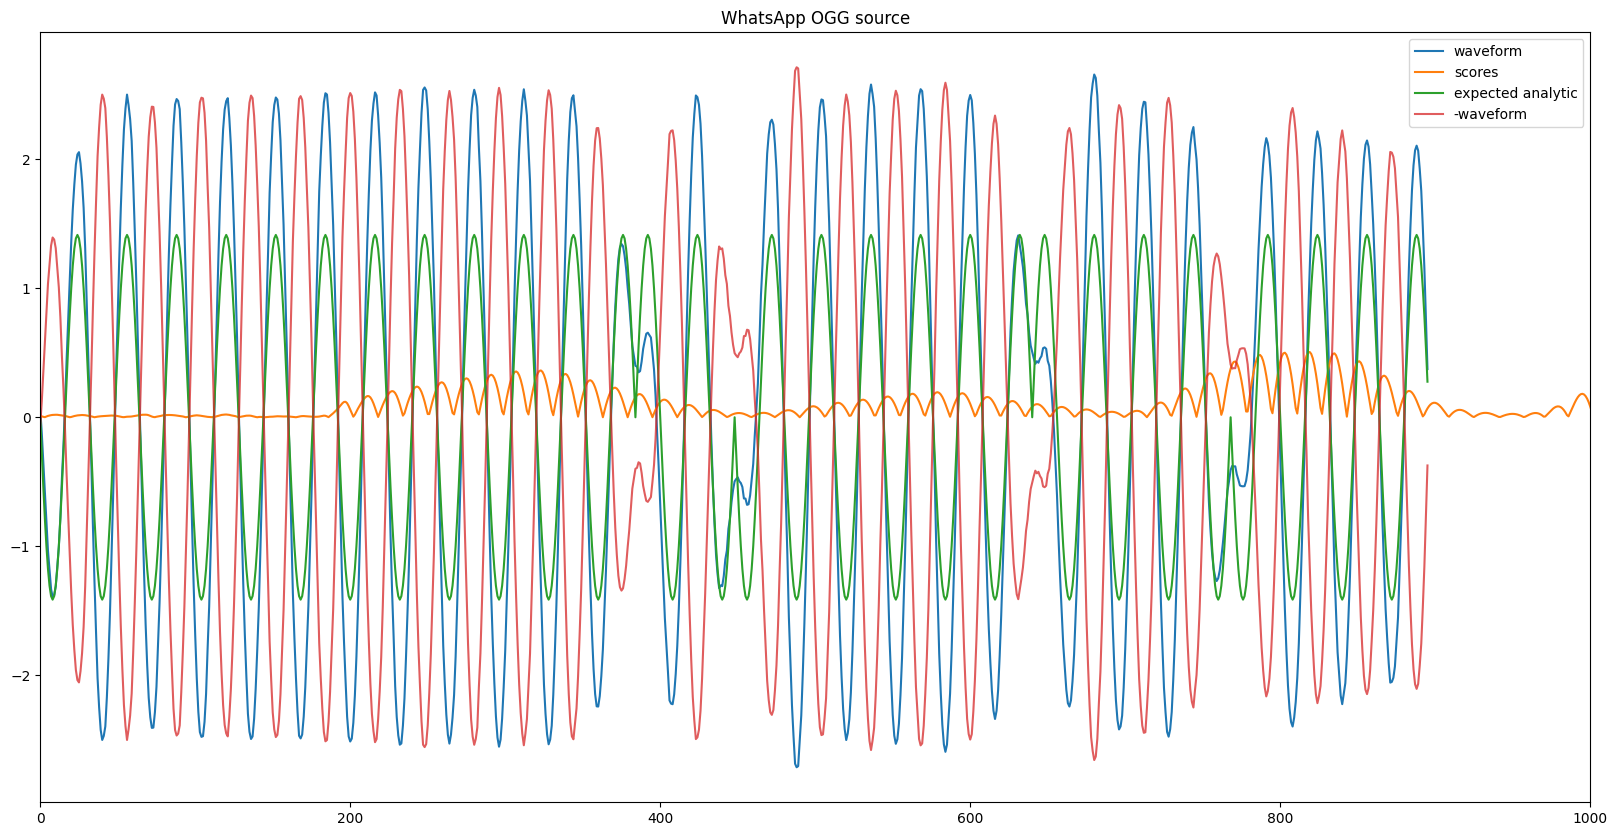

In [27]:
import matplotlib.pyplot as plt
import numpy as np


def _aligned_segment(waveform, scores, expected_analytic):
    start = np.argmax(scores) - expected_analytic.shape[0] // 2
    end = start + expected_analytic.shape[0]
    return waveform[start:end]


def plot_waveform_scores_expected_analytic(
    waveform, scores, expected_analytic, title=None, show_negated=False
):
    waveform = waveform / np.std(waveform)
    expected_analytic = expected_analytic / np.std(expected_analytic)
    aligned_waveform = _aligned_segment(waveform, scores, expected_analytic)

    plt.figure(figsize=(20, 10))
    plt.plot(aligned_waveform[::10], label="waveform")
    plt.plot(scores[::10], label="scores")
    plt.plot(expected_analytic[::10], label="expected analytic")
    if show_negated:
        plt.plot((-aligned_waveform)[::10], label="-waveform", alpha=0.75)
    if title is not None:
        plt.title(title)
    plt.xlim([0, 1000])
    plt.legend()

    print(
        {
            "corr_same": float(
                np.corrcoef(
                    aligned_waveform[: expected_analytic.shape[0]],
                    expected_analytic[: aligned_waveform.shape[0]],
                )[0, 1]
            ),
            "corr_flipped": float(
                np.corrcoef(
                    -aligned_waveform[: expected_analytic.shape[0]],
                    expected_analytic[: aligned_waveform.shape[0]],
                )[0, 1]
            ),
        }
    )


waveform = np.load("../../output/waveform.npy")
scores = np.abs(np.load("../../output/scores.npy"))
expected_analytic = np.load("../../output/expected_analytic.npy")
plot_waveform_scores_expected_analytic(
    waveform,
    scores,
    expected_analytic,
    title="WAV source",
)

waveform2 = np.load("../../output/waveform2.npy")
scores2 = np.abs(np.load("../../output/scores2.npy"))
expected_analytic2 = np.load("../../output/expected_analytic2.npy")
plot_waveform_scores_expected_analytic(
    waveform2,
    scores2,
    expected_analytic2,
    title="WhatsApp OGG source",
    show_negated=True,
)